In [1]:
!pip install sentence-transformers scikit-learn pandas matplotlib seaborn nbformat

In [2]:
import json
import pickle
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')

In [3]:
with open('nepali_movies.json', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)

print(f"Loaded {len(df)} movies")
df.head()

Loaded 1676 movies


,title,genres,plot
0,November Rain,[],Unusual rain in November brings change into the life of Aayush and Sheetal.
1,Katha Kathmandu,"[Romance, Drama]","Stories of... Lust, Love & Life"
2,Mayabi,[Romance],"The story follows Joy, a cheerful and kind person, who falls in love with Arya, a doctor influen..."
3,Aadha Love,[],Adha Love is a commentary on the contemporary Nepali society and draws our attention to the evol...
4,Narasimha Avatar,[Drama],"Set in Kathmandu, Narsimha Avatar is an action thriller in which a feared gangster’s empire is c..."


In [4]:
print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\nSample rows:")
df.sample(5, random_state=42)

Shape: (1676, 3)

Column dtypes:
 title     object
genres    object
plot      object
dtype: object

Sample rows:


,title,genres,plot
864,Hidda Hiddai,"[Comedy, Romance, Love Story, ]","Hiddai Hiddai is a new Nepi movie directed Milan Aale Magar by starring Aakash Shrestha, Rekha S..."
1268,Janayuddha,"[Other, ]",None
416,Pinjada Back Again,"[Drama, Romance, Action, ]","New Nepali Movie - ""PINJADA Back Again "" Official Trailer || Nikhil Upreti, Bishow Sharma, Sa ra..."
1299,Ijjatdar,"[Other, ]",None
1621,Khudkilo,"[Other, ]",None


In [6]:
# Normalize genres: keep as list, drop empty-string entries like the trailing '' you saw above
df['genres'] = df['genres'].apply(
    lambda x: [g.strip() for g in x if isinstance(g, str) and g.strip()] if isinstance(x, list) else []
)

# Normalize plot/title to clean strings (turns None into '')
df['plot'] = df['plot'].apply(lambda x: x.strip() if isinstance(x, str) else '')
df['title'] = df['title'].apply(lambda x: x.strip() if isinstance(x, str) else '')

n_total = len(df)
n_missing_title = (df['title'] == '').sum()
n_missing_plot = (df['plot'] == '').sum()
n_missing_genre = (df['genres'].apply(len) == 0).sum()
n_missing_both = ((df['plot'] == '') & (df['genres'].apply(len) == 0)).sum()
n_dupe_titles = df['title'].str.lower().duplicated(keep=False).sum()

print(f"Total rows:                 {n_total}")
print(f"Missing title:              {n_missing_title}")
print(f"Missing/empty plot:         {n_missing_plot} ({n_missing_plot/n_total:.1%})")
print(f"Missing/empty genres:       {n_missing_genre} ({n_missing_genre/n_total:.1%})")
print(f"Missing BOTH plot & genre:  {n_missing_both}")
print(f"Rows involved in duplicate titles: {n_dupe_titles}")

Total rows:                 1676
Missing title:              1
Missing/empty plot:         782 (46.7%)
Missing/empty genres:       78 (4.7%)
Missing BOTH plot & genre:  22
Rows involved in duplicate titles: 424


In [7]:
before = len(df)

# Drop rows with no title (can't display or look up a movie without one)
df = df[df['title'] != ''].copy()

# Drop rows missing BOTH plot and genre (nothing usable to embed)
df = df[~((df['plot'] == '') & (df['genres'].apply(len) == 0))].copy()

# Fill remaining missing genres with a placeholder
df['genres'] = df['genres'].apply(lambda g: g if len(g) > 0 else ['Unknown'])

# Reset index — this becomes our movie index for the rest of the notebook
df = df.reset_index(drop=True)

print(f"Rows before cleaning: {before}")
print(f"Rows after cleaning:  {len(df)}  (dropped {before - len(df)} unusable rows)")

Rows before cleaning: 1676
Rows after cleaning:  1653  (dropped 23 unusable rows)


In [8]:
def build_combined_text(row):
    genre_text = ', '.join(row['genres'])
    parts = [
        f"Genre: {genre_text}." if genre_text else "",
        row['plot'] if row['plot'] else "",
    ]
    return ' '.join(p for p in parts if p).strip()

df['combined_features'] = df.apply(build_combined_text, axis=1)

# Sanity check: no row should end up empty
assert (df['combined_features'] == '').sum() == 0, "Found rows with empty combined features!"

df[['title', 'genres', 'plot', 'combined_features']].head(5)

,title,genres,plot,combined_features
0,November Rain,[Unknown],Unusual rain in November brings change into the life of Aayush and Sheetal.,Genre: Unknown. Unusual rain in November brings change into the life of Aayush and Sheetal.
1,Katha Kathmandu,"[Romance, Drama]","Stories of... Lust, Love & Life","Genre: Romance, Drama. Stories of... Lust, Love & Life"
2,Mayabi,[Romance],"The story follows Joy, a cheerful and kind person, who falls in love with Arya, a doctor influen...","Genre: Romance. The story follows Joy, a cheerful and kind person, who falls in love with Arya, ..."
3,Aadha Love,[Unknown],Adha Love is a commentary on the contemporary Nepali society and draws our attention to the evol...,Genre: Unknown. Adha Love is a commentary on the contemporary Nepali society and draws our atten...
4,Narasimha Avatar,[Drama],"Set in Kathmandu, Narsimha Avatar is an action thriller in which a feared gangster’s empire is c...","Genre: Drama. Set in Kathmandu, Narsimha Avatar is an action thriller in which a feared gangster..."


In [9]:
from sentence_transformers import SentenceTransformer

MODEL_NAME = 'all-MiniLM-L6-v2'
model = SentenceTransformer(MODEL_NAME)
print(f"Loaded {MODEL_NAME} | embedding dimension: {model.get_sentence_embedding_dimension()}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded all-MiniLM-L6-v2 | embedding dimension: 384


C:\Users\asus\AppData\Local\Temp\ipykernel_16764\564770004.py:5: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Loaded {MODEL_NAME} | embedding dimension: {model.get_sentence_embedding_dimension()}")


In [10]:
embeddings = model.encode(
    df['combined_features'].tolist(),
    show_progress_bar=True,
    batch_size=64,
    convert_to_numpy=True,
)
print("Embeddings shape:", embeddings.shape)  # should be (1653, 384)

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

Embeddings shape: (1653, 384)


In [11]:
similarity_matrix = cosine_similarity(embeddings)
print("Similarity matrix shape:", similarity_matrix.shape)
print("Diagonal check (should all be ~1.0):", np.allclose(np.diag(similarity_matrix), 1.0))

Similarity matrix shape: (1653, 1653)
Diagonal check (should all be ~1.0): True


In [12]:
title_to_indices = {}
for idx, title in df['title'].items():
    key = title.lower().strip()
    title_to_indices.setdefault(key, []).append(idx)

index_to_title = df['title'].to_dict()

print(f"Unique titles: {len(title_to_indices)} | Total movies: {len(df)}")

# Example: show a title that has duplicates
dupes = {k: v for k, v in title_to_indices.items() if len(v) > 1}
example_key = next(iter(dupes))
print(f"\nExample duplicate title '{example_key}' maps to indices: {dupes[example_key]}")

Unique titles: 1442 | Total movies: 1653

Example duplicate title 'november rain' maps to indices: [0, 807]


In [13]:
def recommend_by_index(movie_idx, top_n=10):
    """Core recommender: returns the top_n most similar movies to df.loc[movie_idx]."""
    sim_scores = list(enumerate(similarity_matrix[movie_idx]))
    sim_scores = [s for s in sim_scores if s[0] != movie_idx]  # exclude itself
    sim_scores.sort(key=lambda x: x[1], reverse=True)
    top = sim_scores[:top_n]

    result = df.loc[[i for i, _ in top], ['title', 'genres']].copy()
    result['similarity_score'] = [round(score, 4) for _, score in top]
    return result.reset_index().rename(columns={'index': 'movie_index'})


def recommend_by_title(title, top_n=10):
    """
    Convenience wrapper around recommend_by_index.
    If the title matches multiple movies (duplicates), it warns and uses the first match --
    pass an explicit index via recommend_by_index() if you need a specific one.
    """
    key = title.lower().strip()
    if key not in title_to_indices:
        print(f"'{title}' not found. Try search_movies('{title}') to find close matches.")
        return None

    indices = title_to_indices[key]
    if len(indices) > 1:
        print(f"Note: '{title}' matches {len(indices)} movies (indices {indices}). "
              f"Using index {indices[0]}. Use recommend_by_index(idx) to pick a specific one.")

    return recommend_by_index(indices[0], top_n=top_n)

In [14]:
recommend_by_title('Kabaddi', top_n=5)

Note: 'Kabaddi' matches 2 movies (indices [293, 468]). Using index 293. Use recommend_by_index(idx) to pick a specific one.


,movie_index,title,genres,similarity_score
0,468,Kabaddi,"[Comedy, Drama, Romance]",0.8543
1,457,Kabaddi Kabaddi,"[Comedy, Drama]",0.7922
2,175,Kabaddi Kabaddi Kabaddi,"[Comedy, Drama, Romance]",0.7144
3,269,Kabaddi 4: The Final Match,"[Comedy, Drama]",0.6204
4,117,Kaji,"[Drama, Romance]",0.6109


In [15]:
def search_movies(query, top_n=10):
    """Case-insensitive substring search over movie titles."""
    query = query.lower().strip()
    matches = df[df['title'].str.lower().str.contains(re.escape(query), na=False)]
    return matches[['title', 'genres']].head(top_n)

search_movies('kabaddi')

,title,genres
175,Kabaddi Kabaddi Kabaddi,"[Comedy, Drama, Romance]"
269,Kabaddi 4: The Final Match,"[Comedy, Drama]"
293,Kabaddi,"[Comedy, Drama]"
399,Kabaddi 4: The Final Match,"[Comedy, Adventure]"
414,Kabaddi Kabaddi Kabaddi,"[Comedy, Love Story]"
457,Kabaddi Kabaddi,"[Comedy, Drama]"
468,Kabaddi,"[Comedy, Drama, Romance]"


In [16]:
def recommend_pretty(title=None, movie_idx=None, top_n=10):
    if movie_idx is None:
        key = title.lower().strip()
        if key not in title_to_indices:
            print(f"'{title}' not found. Try search_movies() first.")
            return None
        movie_idx = title_to_indices[key][0]

    query_row = df.loc[movie_idx]
    print(f"Because you liked: \"{query_row['title']}\"")
    print(f"Genres: {', '.join(query_row['genres'])}")
    print(f"Plot: {query_row['plot'][:150] if query_row['plot'] else '(no plot available)'}...")
    print("\nTop recommendations:\n")

    recs = recommend_by_index(movie_idx, top_n=top_n)
    recs['genres'] = recs['genres'].apply(lambda g: ', '.join(g))
    return recs[['title', 'genres', 'similarity_score']]

recommend_pretty('Kabaddi', top_n=5)

Because you liked: "Kabaddi"
Genres: Comedy, Drama
Plot: Aimless Kaji dreams of marrying village girl Maiya by any means. However, she wants to go to the city seeking higher education. Their lives are thrown...

Top recommendations:



,title,genres,similarity_score
0,Kabaddi,"Comedy, Drama, Romance",0.8543
1,Kabaddi Kabaddi,"Comedy, Drama",0.7922
2,Kabaddi Kabaddi Kabaddi,"Comedy, Drama, Romance",0.7144
3,Kabaddi 4: The Final Match,"Comedy, Drama",0.6204
4,Kaji,"Drama, Romance",0.6109


In [17]:
with open('movie_embeddings.pkl', 'wb') as f:
    pickle.dump({
        'embeddings': embeddings,
        'similarity_matrix': similarity_matrix,
        'df': df,
        'model_name': MODEL_NAME,
    }, f)

print("Saved to movie_embeddings.pkl")

Saved to movie_embeddings.pkl


In [18]:
def genre_set(idx):
    return set(g.lower() for g in df.loc[idx, 'genres'])


def precision_recall_at_k(movie_idx, k=10):
    query_genres = genre_set(movie_idx)
    if not query_genres or query_genres == {'unknown'}:
        return None  # skip movies with no real genre info

    total_relevant = sum(
        1 for i in df.index
        if i != movie_idx and genre_set(i) & query_genres
    )
    if total_relevant == 0:
        return None

    recs = recommend_by_index(movie_idx, top_n=k)
    hits = sum(
        1 for _, row in recs.iterrows()
        if set(g.lower() for g in row['genres']) & query_genres
    )

    precision = hits / k
    recall = hits / total_relevant
    return precision, recall


np.random.seed(42)
K = 10
sample_indices = np.random.choice(df.index, size=min(300, len(df)), replace=False)

precisions, recalls = [], []
for idx in sample_indices:
    result = precision_recall_at_k(idx, k=K)
    if result is not None:
        precisions.append(result[0])
        recalls.append(result[1])

print(f"Evaluated on {len(precisions)} movies out of {len(sample_indices)} sampled")
print(f"Precision@{K}: {np.mean(precisions):.3f}")
print(f"Recall@{K}:    {np.mean(recalls):.3f}")

Evaluated on 290 movies out of 300 sampled
Precision@10: 0.863
Recall@10:    0.030


In [19]:
for k_test in [5, 10, 20, 50]:
    precs, recs = [], []
    for idx in sample_indices:
        r = precision_recall_at_k(idx, k=k_test)
        if r is not None:
            precs.append(r[0])
            recs.append(r[1])
    print(f"K={k_test:3d}  Precision@K={np.mean(precs):.3f}   Recall@K={np.mean(recs):.3f}")

K=  5  Precision@K=0.873   Recall@K=0.016
K= 10  Precision@K=0.863   Recall@K=0.030
K= 20  Precision@K=0.846   Recall@K=0.058
K= 50  Precision@K=0.809   Recall@K=0.123


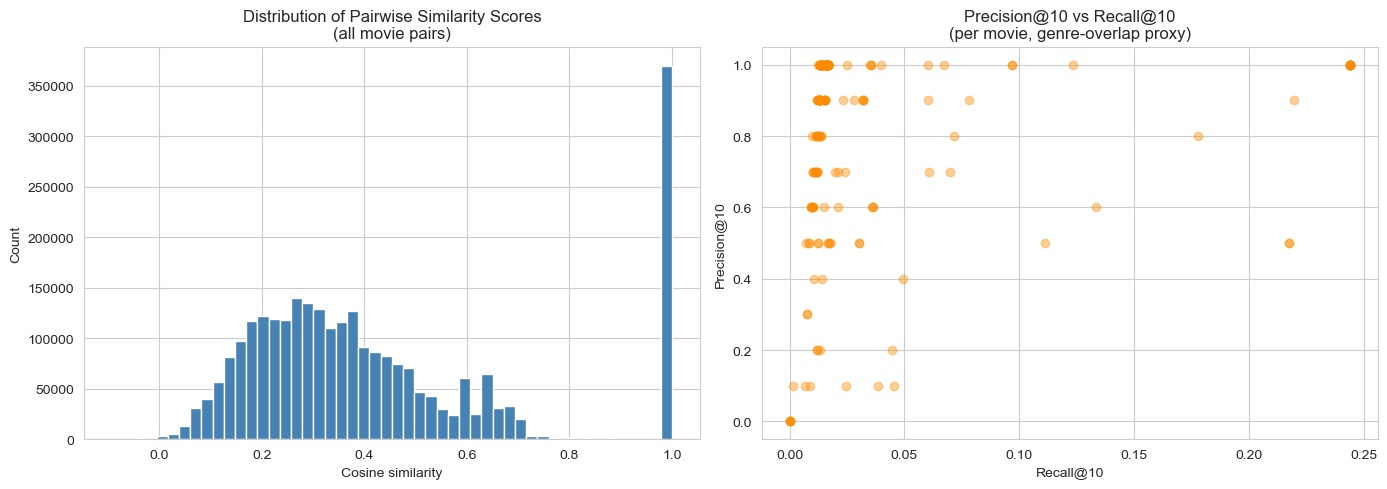

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mask = ~np.eye(similarity_matrix.shape[0], dtype=bool)
all_sims = similarity_matrix[mask]
axes[0].hist(all_sims, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Pairwise Similarity Scores\n(all movie pairs)')
axes[0].set_xlabel('Cosine similarity')
axes[0].set_ylabel('Count')

axes[1].scatter(recalls, precisions, alpha=0.4, color='darkorange')
axes[1].set_title('Precision@10 vs Recall@10\n(per movie, genre-overlap proxy)')
axes[1].set_xlabel('Recall@10')
axes[1].set_ylabel('Precision@10')

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=120)
plt.show()

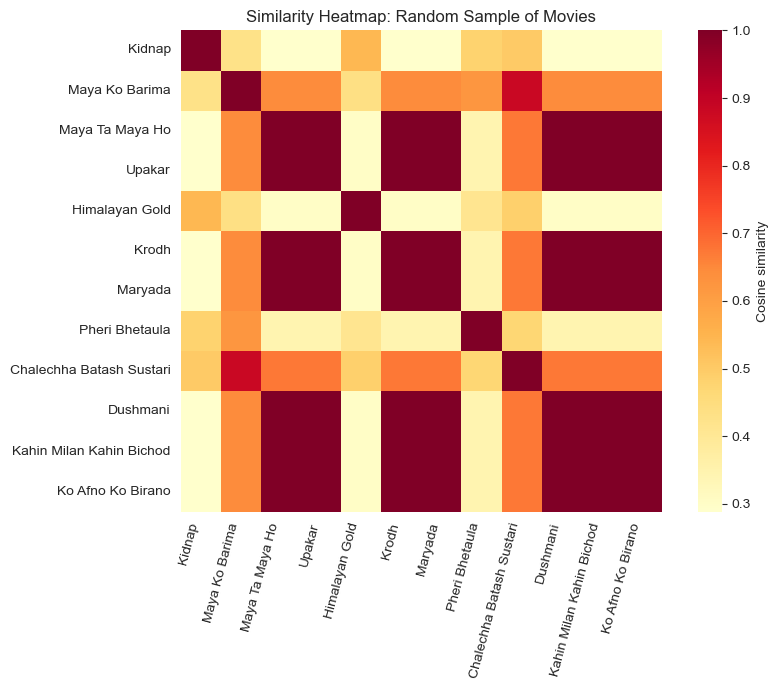

In [21]:
sample_titles = df['title'].drop_duplicates().sample(12, random_state=1).tolist()
sample_idx = [title_to_indices[t.lower()][0] for t in sample_titles]

sub_matrix = similarity_matrix[np.ix_(sample_idx, sample_idx)]

plt.figure(figsize=(9, 7))
sns.heatmap(sub_matrix, xticklabels=sample_titles, yticklabels=sample_titles,
            cmap='YlOrRd', annot=False, square=True, cbar_kws={'label': 'Cosine similarity'})
plt.title('Similarity Heatmap: Random Sample of Movies')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=120)
plt.show()

In [22]:
%%writefile app.py
import pickle
import streamlit as st

st.set_page_config(page_title="Nepali Movie Recommender", page_icon="🎬", layout="centered")

@st.cache_resource
def load_data():
    with open("movie_embeddings.pkl", "rb") as f:
        saved = pickle.load(f)
    return saved["df"], saved["similarity_matrix"]

def recommend_by_index(df, similarity_matrix, movie_idx, top_n=5):
    sim_scores = list(enumerate(similarity_matrix[movie_idx]))
    sim_scores = [s for s in sim_scores if s[0] != movie_idx]
    sim_scores.sort(key=lambda x: x[1], reverse=True)
    top = sim_scores[:top_n]
    result = df.loc[[i for i, _ in top], ["title", "genres"]].copy()
    result["similarity_score"] = [round(score, 4) for _, score in top]
    return result.reset_index().rename(columns={"index": "movie_index"})

st.title("🎬 Nepali Movie Recommender")

df, similarity_matrix = load_data()
st.write(f"Catalog: **{len(df)}** movies")

query = st.text_input("Search for a movie you like", placeholder="e.g. Kabaddi")

if query:
    matches = df[df["title"].str.lower().str.contains(query.lower().strip(), na=False)]
    if matches.empty:
        st.warning(f"No movies found matching '{query}'.")
    else:
        options = {
            f"{row.title} ({', '.join(row.genres) if row.genres else 'Unknown'}) [#{idx}]": idx
            for idx, row in matches.iterrows()
        }
        choice = st.selectbox(f"Found {len(matches)} match(es):", options.keys())
        idx = options[choice]
        selected = df.loc[idx]

        st.subheader(f"Because you liked: {selected.title}")
        st.write(f"**Genres:** {', '.join(selected.genres) if selected.genres else 'Unknown'}")

        st.divider()
        st.subheader("Top 5 similar movies")
        recs = recommend_by_index(df, similarity_matrix, idx, top_n=5)
        recs["genres"] = recs["genres"].apply(lambda g: ", ".join(g) if g else "Unknown")
        for _, row in recs.iterrows():
            st.markdown(f"**{row.title}** — {row.genres}")
            st.caption(f"Similarity: {row.similarity_score:.2f}")

Writing app.py
